In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

: 

In [49]:
df = pd.read_csv('/content/_study_data.csv')

In [50]:
df.head()

,sleep_hours,focus_level,free_time,days_left,study_time
0,5.87,8.19,3.11,2,8.76
1,8.75,7.22,5.25,6,9.06
2,7.66,5.86,7.24,12,6.59
3,6.99,8.88,6.39,5,9.85
4,4.78,8.11,6.84,13,7.29


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sleep_hours  500 non-null    float64
 1   focus_level  500 non-null    float64
 2   free_time    500 non-null    float64
 3   days_left    500 non-null    int64  
 4   study_time   500 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 19.7 KB


In [52]:
df.isnull().sum()

,0
sleep_hours,0
focus_level,0
free_time,0
days_left,0
study_time,0


In [53]:
df.describe()

,sleep_hours,focus_level,free_time,days_left,study_time
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,6.492900,6.891500,5.105340,7.366000,7.934400
std,1.493406,1.712958,1.783217,4.057212,1.380237
min,4.030000,4.030000,2.030000,1.000000,4.070000
25%,5.207500,5.377500,3.445000,4.000000,6.895000
50%,6.565000,6.830000,5.240000,7.000000,7.965000
75%,7.782500,8.355000,6.665000,11.000000,8.950000
max,8.960000,10.000000,8.000000,14.000000,11.820000


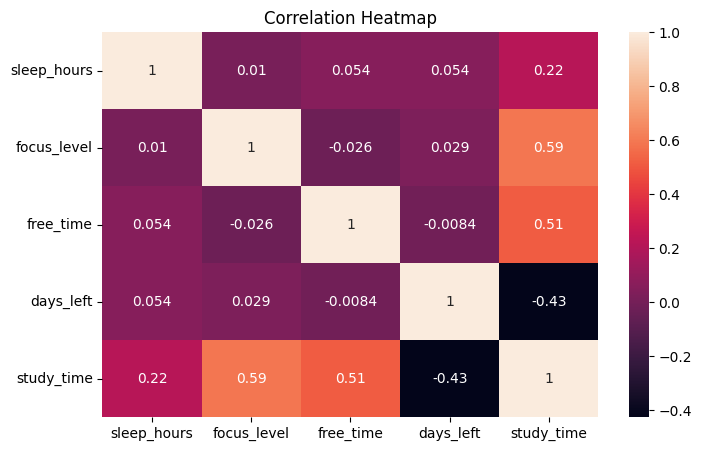

In [54]:

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

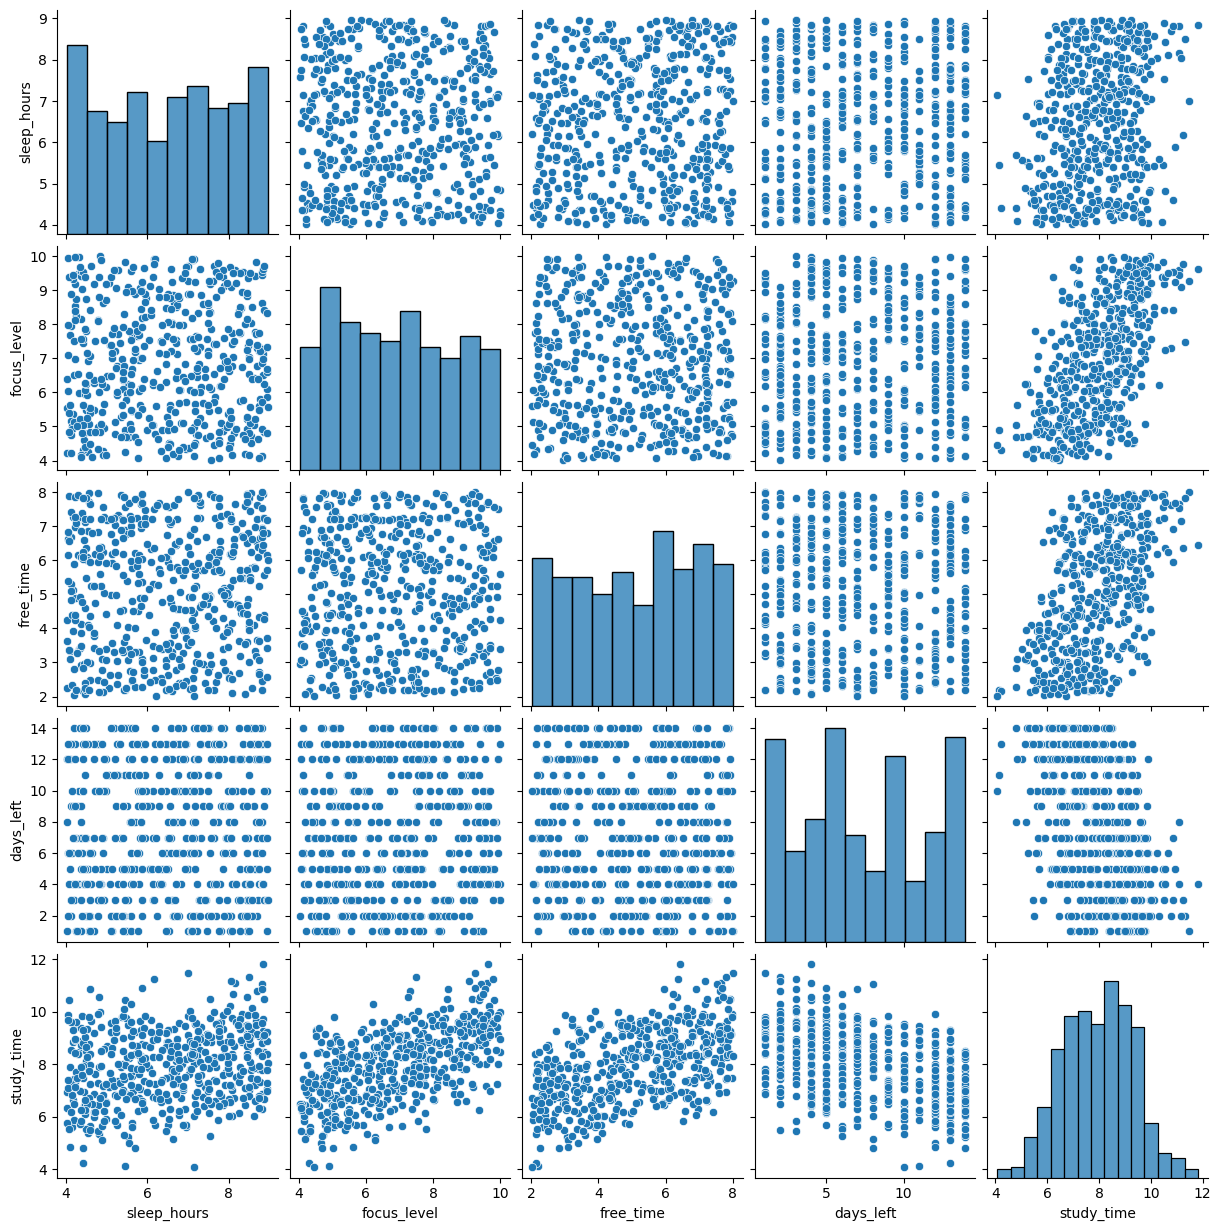

In [55]:
sns.pairplot(df)

In [56]:
X = df[['sleep_hours', 'focus_level', 'free_time', 'days_left']]
y = df['study_time']

In [57]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [58]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
print("Model trained ✅")

Model trained ✅


In [59]:
y_pred = lr.predict(X_test)

In [60]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
score = r2_score(y_test,y_pred)
print(f"The r2 score is : {score*100:.2f}%")
mse = mean_squared_error(y_test,y_pred)
print(f"The mean squared error is : {mse}")
mae = mean_absolute_error(y_test,y_pred)
print(f"The mean absolute error is : {mae}")
rmse = np.sqrt(mse)
print(f"The Root mean squared error is : {rmse}")


The r2 score is : 81.62%
The mean squared error is : 0.32536779357914897
The mean absolute error is : 0.45884430602082477
The Root mean squared error is : 0.5704101976465261


In [61]:
import joblib

joblib.dump(lr, "study_model.pkl")

['study_model.pkl']

In [62]:
from google.colab import files
files.download("study_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>